In [1]:
!pip install -q segmentation-models-pytorch

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.0 MB/s eta 0:00:00


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=104
).to(device)

In [5]:
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/foodseg_best_model.pth",
    map_location=device
))

model.eval()
print("Model loaded successfully.")

Model loaded successfully.


In [6]:
category_path = "/content/drive/MyDrive/category_id.txt"
print(category_path)

/content/drive/MyDrive/category_id.txt


In [7]:
id_to_name = {}

with open(category_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        parts = line.split()
        class_id = int(parts[0])
        class_name = " ".join(parts[1:])  # join everything after ID

        id_to_name[class_id] = class_name.lower()

print("Total classes loaded:", len(id_to_name))

Total classes loaded: 104


In [8]:
print(id_to_name[18])
print(id_to_name[48])

red beans
chicken duck


In [9]:
for i in range(104):
  print(id_to_name[i])

background
candy
egg tart
french fries
chocolate
biscuit
popcorn
pudding
ice cream
cheese butter
cake
wine
milkshake
coffee
juice
milk
tea
almond
red beans
cashew
dried cranberries
soy
walnut
peanut
egg
apple
date
apricot
avocado
banana
strawberry
cherry
blueberry
raspberry
mango
olives
peach
lemon
pear
fig
pineapple
grape
kiwi
melon
orange
watermelon
steak
pork
chicken duck
sausage
fried meat
lamb
sauce
crab
fish
shellfish
shrimp
soup
bread
corn
hamburg
pizza
hanamaki baozi
wonton dumplings
pasta
noodles
rice
pie
tofu
eggplant
potato
garlic
cauliflower
tomato
kelp
seaweed
spring onion
rape
ginger
okra
lettuce
pumpkin
cucumber
white radish
carrot
asparagus
bamboo shoots
broccoli
celery stick
cilantro mint
snow peas
cabbage
bean sprouts
onion
pepper
green beans
french beans
king oyster mushroom
shiitake
enoki mushroom
oyster mushroom
white button mushroom
salad
other ingredients


In [11]:
def get_food_group(food_name):
    food_name = food_name.lower()

    # Rice & grains
    if any(word in food_name for word in ["rice", "noodles", "pasta", "bread", "corn", "pie"]):
        return "Grains"

    # Meat
    elif any(word in food_name for word in ["steak", "pork", "chicken", "duck", "sausage", "lamb", "fried meat"]):
        return "Meat"

    # Seafood
    elif any(word in food_name for word in ["fish", "shrimp", "crab", "shellfish"]):
        return "Seafood"

    # Vegetables
    elif any(word in food_name for word in [
        "eggplant","potato","garlic","cauliflower","tomato","kelp","seaweed",
        "spring onion","rape","ginger","okra","lettuce","pumpkin","cucumber",
        "radish","carrot","asparagus","bamboo","broccoli","celery","mint",
        "peas","cabbage","bean sprouts","onion","pepper","beans","mushroom",
        "salad"
    ]):
        return "Vegetables"

    # Fruits
    elif any(word in food_name for word in [
        "apple","date","apricot","avocado","banana","strawberry","cherry",
        "blueberry","raspberry","mango","peach","lemon","pear","fig",
        "pineapple","grape","kiwi","melon","orange","watermelon"
    ]):
        return "Fruits"

    # Nuts & beans
    elif any(word in food_name for word in [
        "almond","cashew","walnut","peanut","red beans","soy"
    ]):
        return "Nuts & Beans"

    # Dairy & drinks
    elif any(word in food_name for word in [
        "milk","cheese","butter","milkshake","coffee","juice","tea","wine"
    ]):
        return "Dairy & Drinks"

    # Snacks & desserts
    elif any(word in food_name for word in [
        "cake","ice cream","pudding","biscuit","chocolate","candy","popcorn","egg tart"
    ]):
        return "Desserts"

    # Fast food
    elif any(word in food_name for word in [
        "pizza","hamburg","fries"
    ]):
        return "Fast Food"

    else:
        return "Other"
group_calories = {
    "Grains": 130,
    "Meat": 250,
    "Seafood": 200,
    "Vegetables": 50,
    "Fruits": 80,
    "Nuts & Beans": 550,
    "Dairy & Drinks": 120,
    "Desserts": 400,
    "Fast Food": 300,
    "Other": 100
}

In [24]:
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, (320, 320))
    image_norm = image_resized / 255.0

    tensor = torch.tensor(image_norm, dtype=torch.float32).permute(2,0,1)
    return tensor, image_resized

In [27]:
def run_demo(image_tensor, original_image):
    image_input = image_tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_input)
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    unique_classes = np.unique(pred_mask)
    unique_classes = unique_classes[unique_classes != 0]

    # ---- NEW MASS ESTIMATION LOGIC ----
    total_pixels = pred_mask.size
    food_pixels = np.sum(pred_mask != 0)

    if food_pixels == 0:
        print("No food detected.")
        return

    food_ratio = food_pixels / total_pixels

    # Assume realistic total plate weight
    estimated_plate_weight = 500  # grams
    total_food_grams = food_ratio * estimated_plate_weight

    group_mass = {}

    for cls in unique_classes:
        class_pixels = np.sum(pred_mask == cls)
        class_ratio = class_pixels / food_pixels
        grams = class_ratio * total_food_grams

        food_name = id_to_name.get(cls, "unknown")
        group = get_food_group(food_name)

        group_mass[group] = group_mass.get(group, 0) + grams

    total_calories = 0

    print("\n====== CALORIE ESTIMATION ======")

    for group, grams in group_mass.items():
        kcal = group_calories[group]
        calories = (grams / 100) * kcal
        total_calories += calories
        print(f"{group}: {calories:.2f} kcal")

    print("--------------------------------")
    print(f"Total Calories: {total_calories:.2f} kcal")
    print("================================\n")

    # ---- Visualization ----
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(original_image)
    plt.title("Input Image")

    plt.subplot(1,3,2)
    plt.imshow(pred_mask)
    plt.title("Predicted Mask")

    plt.subplot(1,3,3)
    plt.imshow(original_image)
    plt.imshow(pred_mask, alpha=0.5)
    plt.title("Overlay")

    plt.show()

Saving train.png to train (5).png

====== CALORIE ESTIMATION ======
Vegetables: 132.40 kcal
Meat: 0.04 kcal
Seafood: 55.73 kcal
Grains: 78.41 kcal
Other: 6.21 kcal
--------------------------------
Total Calories: 272.79 kcal



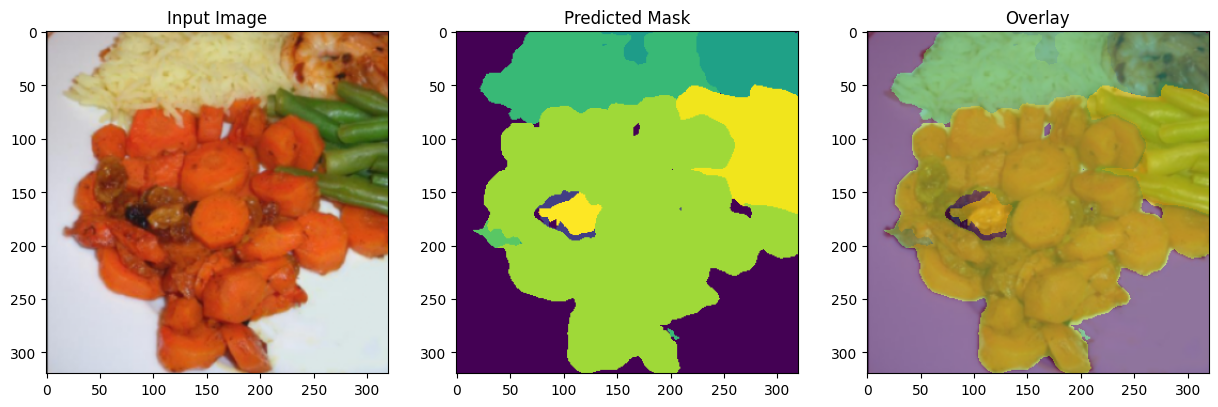

In [30]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image_tensor, original_image = preprocess_image(image_path)

run_demo(image_tensor, original_image)